# 📈 Cuaderno 03 — Regresión Lineal
**Rol:** Experto en Estadística  
**Proyecto:** Predicción de Adicción a Redes Sociales en Estudiantes  
**Variable objetivo:** `Addicted_Score` (continua · rango 2–9)

---
**Objetivo:** Predecir cuantitativamente el puntaje de adicción e interpretar qué
variables lo aumentan más, para diseñar programas de prevención personalizados.

> 🔑 **¿Por qué Regresión Lineal?**  
> Cuando el objetivo es una variable numérica continua y queremos entender el
> **efecto cuantitativo** de cada factor, la Regresión Lineal proporciona coeficientes
> interpretables: "1 hora más de uso aumenta el puntaje de adicción en β unidades."

## 📦 Paso 1 — Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ Librerías importadas")


✅ Librerías importadas


## 📂 Paso 2 — Carga y exploración inicial del dataset

In [9]:
for ruta in ['/content/adiccion_regresion_lineal.csv','adiccion_regresion_lineal.csv']:
    try:
        df = pd.read_csv(ruta); print(f"✅ {ruta}"); break
    except FileNotFoundError: continue
else:
    raise FileNotFoundError("❌ No se encontró 'adiccion_regresion_lineal.csv'. Ejecutar ETL primero.")

OBJETIVO = 'Addicted_Score'
FEATURES = [c for c in df.columns if c != OBJETIVO]

print(f"\n📐 {df.shape[0]} estudiantes × {df.shape[1]} columnas")
print(f"🎯 Objetivo: {OBJETIVO} — Media={df[OBJETIVO].mean():.3f} | Desv={df[OBJETIVO].std():.3f}")
print(f"📋 Features ({len(FEATURES)}): {FEATURES}")

# Obtener las estadísticas descriptivas
descriptive_stats = df[FEATURES + [OBJETIVO]].describe().round(2)

# Traducir el índice (filas) de las estadísticas descriptivas
translations_index = {
    'count': 'Conteo',
    'mean': 'Media',
    'std': 'Desv. Estándar',
    'min': 'Mínimo',
    '25%': '25%',
    '50%': '50% (Mediana)',
    '75%': '75%',
    'max': 'Máximo'
}
descriptive_stats = descriptive_stats.rename(index=translations_index)

# Traducir los nombres de las columnas (características) para la visualización
translations_columns = {
    'Student_ID': 'ID_Estudiante',
    'Age': 'Edad',
    'Gender': 'Género',
    'Academic_Level': 'Nivel_Académico',
    'Country': 'País',
    'Avg_Daily_Usage_Hours': 'Horas_Uso_Diario_Promedio',
    'Most_Used_Platform': 'Plataforma_Más_Usada',
    'Affects_Academic_Performance': 'Afecta_Rendimiento_Académico',
    'Sleep_Hours_Per_Night': 'Horas_Sueño_Por_Noche',
    'Mental_Health_Score': 'Puntaje_Salud_Mental',
    'Relationship_Status': 'Estado_Relación',
    'Conflicts_Over_Social_Media': 'Conflictos_Por_Redes_Sociales',
    'Addicted_Score': 'Puntaje_Adicción' # El objetivo también puede aparecer aquí
}
descriptive_stats = descriptive_stats.rename(columns=translations_columns)

display(descriptive_stats)

✅ /content/adiccion_regresion_lineal.csv

📐 705 estudiantes × 13 columnas
🎯 Objetivo: Addicted_Score — Media=6.437 | Desv=1.587
📋 Features (12): ['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media']


,ID_Estudiante,Edad,Horas_Uso_Diario_Promedio,Horas_Sueño_Por_Noche,Puntaje_Salud_Mental,Conflictos_Por_Redes_Sociales,Puntaje_Adicción
Conteo,705.00,705.00,705.00,705.00,705.00,705.00,705.00
Media,353.00,20.66,4.92,6.87,6.23,2.85,6.44
Desv. Estándar,203.66,1.40,1.26,1.13,1.11,0.96,1.59
Mínimo,1.00,18.00,1.50,3.80,4.00,0.00,2.00
25%,177.00,19.00,4.10,6.00,5.00,2.00,5.00
50% (Mediana),353.00,21.00,4.80,6.90,6.00,3.00,7.00
75%,529.00,22.00,5.80,7.70,7.00,4.00,8.00
Máximo,705.00,24.00,8.50,9.60,9.00,5.00,9.00


## 🔧 Paso 3 — Preprocesamiento y selección de features

In [14]:
X = df[FEATURES].copy()
y = df[OBJETIVO].copy()

# Identificar columnas categóricas para one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Aplicar one-hot encoding a las features categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Actualizar la lista de FEATURES con las nuevas columnas one-hot encoded
FEATURES_ENCODED = X.columns.tolist()

# Escalar features numéricas para hacer comparables los coeficientes
scaler = StandardScaler()
X_esc = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES_ENCODED)

print("✅ Características escaladas con StandardScaler")
print("   (Importante: los coeficientes β se interpretan en desviaciones estándar)\n")

# Correlación previa con el objetivo (usando el dataframe original para las correlaciones de Pearson)
print("Correlaciones con Puntaje_Adicción (antes de escalar, para interpretación de magnitud):")
print(f"  {'Característica':<32} {'r':>8}  Interpretación")
print(f"  {'-'*32} {'-'*8}  {'-'*25}")

# Calcular correlaciones para las columnas numéricas originales y las nuevas columnas one-hot encoded
for col in df[FEATURES].select_dtypes(include=np.number).columns: # Correlaciones para columnas numéricas originales
    r, p = pearsonr(df[col], y)
    sig = '✅' if p<0.05 else '  '
    dir_ = 'aumenta adicción' if r>0 else 'reduce adicción'
    print(f"  {sig} {col:<30} {r:+.4f}  {dir_}")

for col in X.drop(columns=df[FEATURES].select_dtypes(include=np.number).columns).columns: # Correlaciones para las nuevas columnas one-hot encoded
    r, p = pearsonr(X[col], y)
    sig = '✅' if p<0.05 else '  '
    dir_ = 'aumenta adicción' if r>0 else 'reduce adicción'
    print(f"  {sig} {col:<30} {r:+.4f}  {dir_}")

✅ Características escaladas con StandardScaler
   (Importante: los coeficientes β se interpretan en desviaciones estándar)

Correlaciones con Puntaje_Adicción (antes de escalar, para interpretación de magnitud):
  Característica                          r  Interpretación
  -------------------------------- --------  -------------------------
     Student_ID                     +0.0416  aumenta adicción
  ✅ Age                            -0.1664  reduce adicción
  ✅ Avg_Daily_Usage_Hours          +0.8320  aumenta adicción
  ✅ Sleep_Hours_Per_Night          -0.7649  reduce adicción
  ✅ Mental_Health_Score            -0.9451  reduce adicción
  ✅ Conflicts_Over_Social_Media    +0.9336  aumenta adicción
     Gender_Male                    -0.0497  reduce adicción
  ✅ Academic_Level_High School     +0.2013  aumenta adicción
     Academic_Level_Undergraduate   +0.0354  aumenta adicción
     Country_Albania                +0.0134  aumenta adicción
     Country_Andorra                +0.0371  au

## 🔍 Paso 4 — Análisis exploratorio específico del modelo

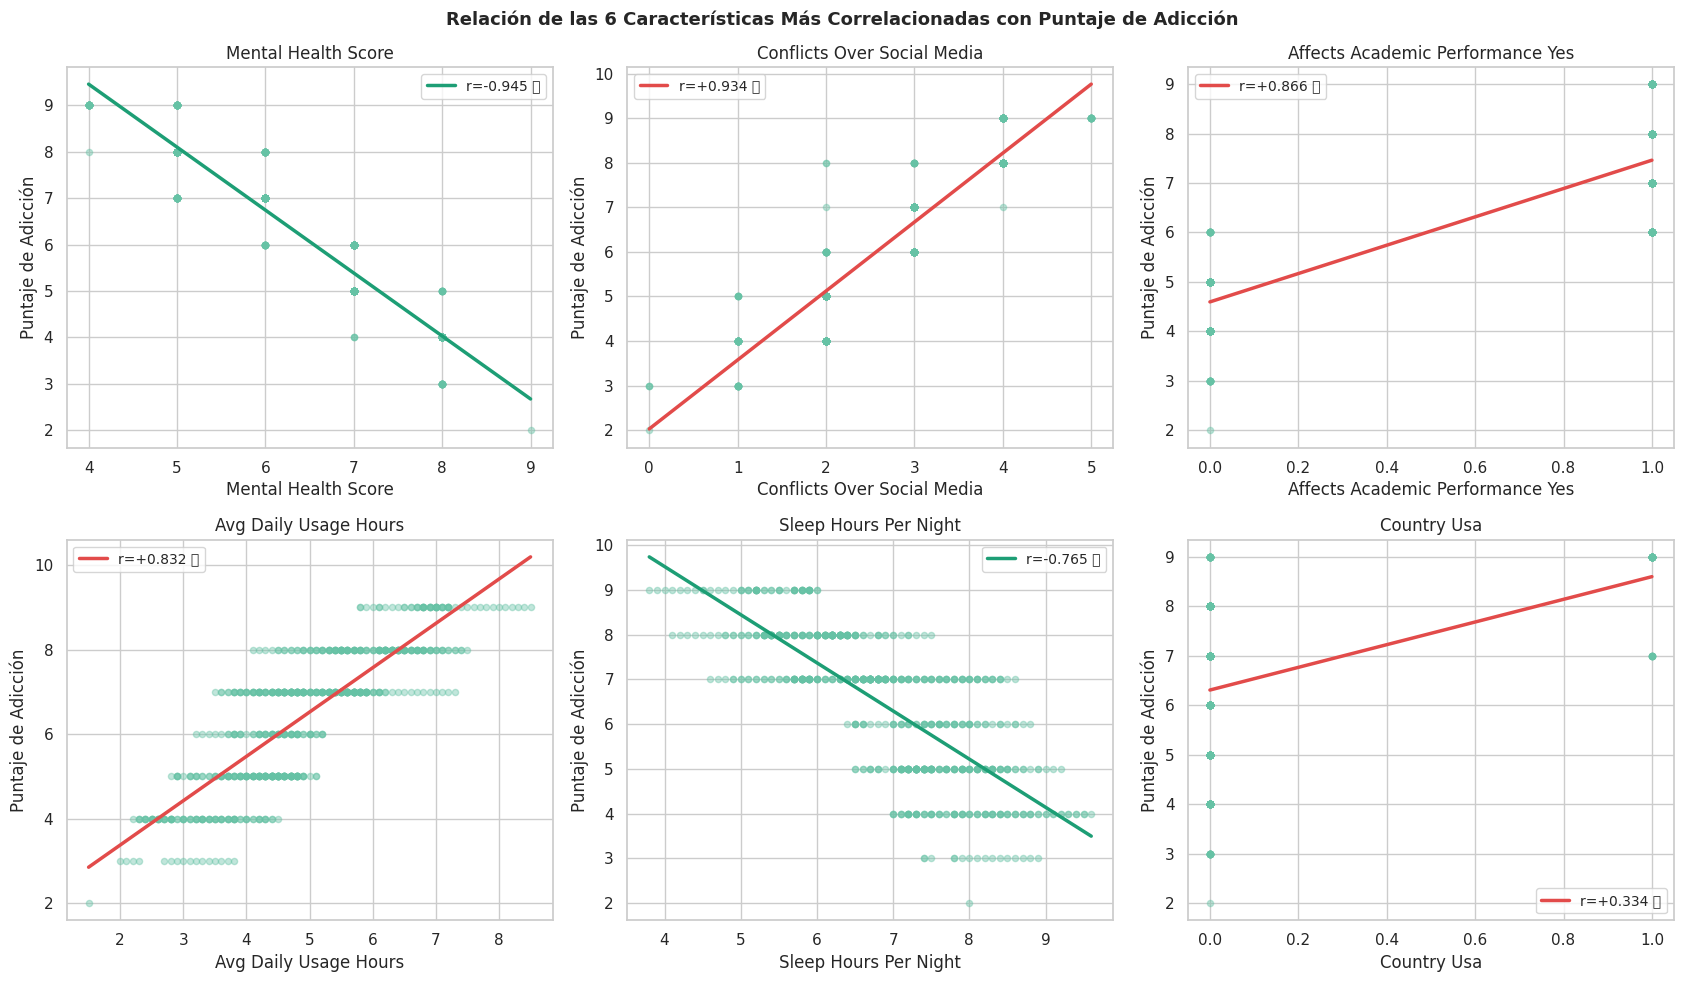

✅ Guardada: lineal_exploratorio.png


In [15]:
# Relación visual de las 6 features más correlacionadas con el objetivo
# Usamos X (con one-hot encoding) para calcular las correlaciones
top_features = sorted(FEATURES_ENCODED, key=lambda c: abs(X[c].corr(y)), reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Relación de las 6 Características Más Correlacionadas con Puntaje de Adicción',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    r, p = pearsonr(X[feat], y) # Usamos X para las correlaciones y los datos para el scatter
    ax.scatter(X[feat], y, alpha=0.4, s=20, color=sns.color_palette('Set2')[0])
    z = np.polyfit(X[feat], y, 1)
    xr = np.linspace(X[feat].min(), X[feat].max(), 100)
    color_trend = '#E24B4A' if r > 0 else '#1D9E75'
    ax.plot(xr, np.poly1d(z)(xr), '-', lw=2.5, color=color_trend,
            label=f'r={r:+.3f} {"✅" if p<0.05 else ""}')
    nombre = feat.replace('_',' ').title()
    ax.set_title(f'{nombre}')
    ax.set_xlabel(nombre)
    ax.set_ylabel('Puntaje de Adicción')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('lineal_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: lineal_exploratorio.png")

## ✂️ Paso 5 — División del dataset (entrenamiento / prueba)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_esc, y, test_size=0.2, random_state=42)

print(f"✅ División 80/20 con random_state=42:")
print(f"   Entrenamiento : {X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.0f}%)  → ajustar el modelo")
print(f"   Prueba        : {X_test.shape[0]}  ({X_test.shape[0]/len(y)*100:.0f}%)  → evaluar sin sesgo")
print(f"\n   Media y_train : {y_train.mean():.3f}  (representativa del total)")
print(f"   Media y_test  : {y_test.mean():.3f}")


✅ División 80/20 con random_state=42:
   Entrenamiento : 564 (80%)  → ajustar el modelo
   Prueba        : 141  (20%)  → evaluar sin sesgo

   Media y_train : 6.454  (representativa del total)
   Media y_test  : 6.369


## 🤖 Paso 6 — Entrenamiento del modelo

In [19]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
print("✅ Regresión Lineal entrenada")
print(f"   Intercepto β₀ = {modelo.intercept_:.4f}")

# Tabla de coeficientes interpretada
coefs = pd.DataFrame({
    'Feature':               FEATURES_ENCODED, # Usar FEATURES_ENCODED aquí
    'Coef. β (escalado)':    modelo.coef_,
    '|β| Importancia':       np.abs(modelo.coef_),
    'Efecto':               ['↑ Aumenta adicción' if b>0 else '↓ Reduce adicción' for b in modelo.coef_]
}).sort_values('|β| Importancia', ascending=False).reset_index(drop=True)

print("\n📊 Coeficientes del modelo (ordenados por importancia):")
display(coefs.round(4))

✅ Regresión Lineal entrenada
   Intercepto β₀ = 6.4639

📊 Coeficientes del modelo (ordenados por importancia):


,Feature,Coef. β (escalado),|β| Importancia,Efecto
0,Mental_Health_Score,-0.6128,0.6128,↓ Reduce adicción
1,Conflicts_Over_Social_Media,0.4544,0.4544,↑ Aumenta adicción
2,Affects_Academic_Performance_Yes,0.2891,0.2891,↑ Aumenta adicción
3,Avg_Daily_Usage_Hours,0.1994,0.1994,↑ Aumenta adicción
4,Relationship_Status_In Relationship,0.1820,0.1820,↑ Aumenta adicción
...,...,...,...,...
127,Country_Ukraine,0.0000,0.0000,↑ Aumenta adicción
128,Country_Kyrgyzstan,0.0000,0.0000,↑ Aumenta adicción
129,Country_Vietnam,-0.0000,0.0000,↓ Reduce adicción
130,Country_Tajikistan,0.0000,0.0000,↑ Aumenta adicción


## 🔮 Paso 7 — Predicciones sobre el conjunto de prueba

In [20]:
y_pred = modelo.predict(X_test)
y_pred_clip = np.clip(y_pred, 2, 9)  # ajustar al rango válido

print("📋 Comparación Real vs Predicho (primeras 20 muestras):")
cmp = pd.DataFrame({
    'Real':              y_test.values[:20],
    'Predicho (raw)':    y_pred[:20].round(2),
    'Predicho (recorte)':y_pred_clip[:20].round(2),
    'Error abs.':        np.abs(y_test.values[:20] - y_pred[:20]).round(2)
})
display(cmp.style.background_gradient(subset=['Error abs.'], cmap='RdYlGn_r'))


📋 Comparación Real vs Predicho (primeras 20 muestras):


,Real,Predicho (raw),Predicho (recorte),Error abs.
0,5,4.830000,4.830000,0.170000
1,7,7.500000,7.500000,0.500000
2,5,5.640000,5.640000,0.640000
3,7,7.130000,7.130000,0.130000
4,4,3.720000,3.720000,0.280000
5,9,8.700000,8.700000,0.300000
6,3,3.070000,3.070000,0.070000
7,4,4.320000,4.320000,0.320000
8,5,5.010000,5.010000,0.010000
9,7,6.980000,6.980000,0.020000


## 📏 Paso 8 — Métricas de evaluación

In [21]:
ecm    = mean_squared_error(y_test, y_pred)
recm   = np.sqrt(ecm)
eam    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)
r2_cv  = cross_val_score(LinearRegression(), X_esc, y, cv=5, scoring='r2')

print("═"*58)
print("  MÉTRICAS — REGRESIÓN LINEAL (Conjunto de Prueba)")
print("═"*58)
print(f"  R²  (Coef. Determinación)    : {r2:.4f}")
print(f"  ECM (Error Cuadrático Medio) : {ecm:.4f}")
print(f"  RECM (Raíz del ECM)          : {recm:.4f}  ← en unidades del score")
print(f"  EAM (Error Absoluto Medio)   : {eam:.4f}  ← desviación promedio")
print(f"  R² Validación Cruzada (5CV)  : {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")
print("═"*58)
print(f"\n  INTERPRETACIÓN:")
print(f"  → El modelo explica el {r2*100:.1f}% de la varianza en el puntaje de adicción")
print(f"  → En promedio, las predicciones se desvían ±{eam:.2f} puntos del real")
print(f"  → R² estable en CV ({r2_cv.mean():.3f}) = modelo no sobreajustado (overfitting)")


══════════════════════════════════════════════════════════
  MÉTRICAS — REGRESIÓN LINEAL (Conjunto de Prueba)
══════════════════════════════════════════════════════════
  R²  (Coef. Determinación)    : 0.9347
  ECM (Error Cuadrático Medio) : 0.1635
  RECM (Raíz del ECM)          : 0.4043  ← en unidades del score
  EAM (Error Absoluto Medio)   : 0.2560  ← desviación promedio
  R² Validación Cruzada (5CV)  : 0.9265 ± 0.0324
══════════════════════════════════════════════════════════

  INTERPRETACIÓN:
  → El modelo explica el 93.5% de la varianza en el puntaje de adicción
  → En promedio, las predicciones se desvían ±0.26 puntos del real
  → R² estable en CV (0.927) = modelo no sobreajustado (overfitting)


## 📉 Paso 9 — Visualizaciones del modelo

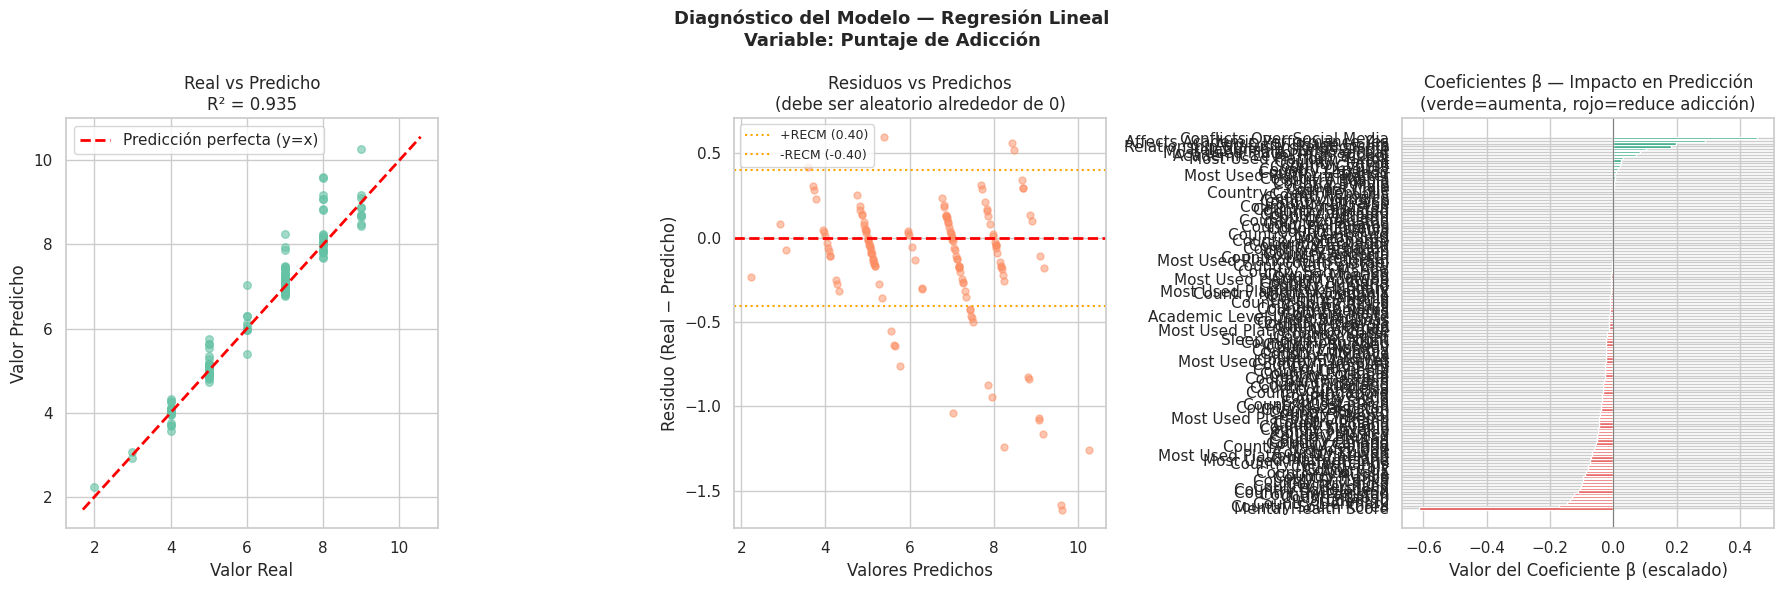

✅ Guardada: lineal_diagnostico.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Diagnóstico del Modelo — Regresión Lineal\nVariable: Puntaje de Adicción',
             fontsize=13, fontweight='bold')

# A) Real vs Predicho
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.6, s=30, color=sns.color_palette('Set2')[0])
lim = [min(y_test.min(), y_pred.min())-0.3, max(y_test.max(), y_pred.max())+0.3]
ax.plot(lim, lim, 'r--', lw=2, label='Predicción perfecta (y=x)')
ax.set_xlabel('Valor Real')
ax.set_ylabel('Valor Predicho')
ax.set_title(f'Real vs Predicho\nR² = {r2:.3f}')
ax.legend()

# B) Residuos vs predichos
residuos = y_test.values - y_pred
ax = axes[1]
ax.scatter(y_pred, residuos, alpha=0.5, s=25, color=sns.color_palette('Set2')[1])
ax.axhline(0, color='red', ls='--', lw=2)
ax.axhline(recm, color='orange', ls=':', lw=1.5, label=f'+RECM ({recm:.2f})')
ax.axhline(-recm, color='orange', ls=':', lw=1.5, label=f'-RECM ({-recm:.2f})')
ax.set_xlabel('Valores Predichos')
ax.set_ylabel('Residuo (Real − Predicho)')
ax.set_title('Residuos vs Predichos\n(debe ser aleatorio alrededor de 0)')
ax.legend(fontsize=9)

# C) Importancia de coeficientes β
ax = axes[2]
coefs_sorted = coefs.sort_values('Coef. β (escalado)')
colores_bar = ['#1D9E75' if v > 0 else '#E24B4A' for v in coefs_sorted['Coef. β (escalado)']]
ax.barh(coefs_sorted['Feature'].str.replace('_',' ').str.title(),
        coefs_sorted['Coef. β (escalado)'], color=colores_bar, edgecolor='white')
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Coeficientes β — Impacto en Predicción\n(verde=aumenta, rojo=reduce adicción)')
ax.set_xlabel('Valor del Coeficiente β (escalado)')

plt.tight_layout()
plt.savefig('lineal_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: lineal_diagnostico.png")


## 📝 Paso 10 — Conclusiones e interpretación para prevención

In [23]:
# Identificar los 3 factores que más aumentan y más reducen la adicción
aumentan = coefs[coefs['Coef. β (escalado)']>0].nlargest(3,'|β| Importancia')
reducen  = coefs[coefs['Coef. β (escalado)']<0].nlargest(3,'|β| Importancia')

print("""
╔══════════════════════════════════════════════════════════════════╗
║     CONCLUSIONES — REGRESIÓN LINEAL (Análisis de Impacto)        ║
╚══════════════════════════════════════════════════════════════════╝
""")
print(f"  MODELO: Regresión Lineal | R²={r2:.3f} | RECM={recm:.3f} | EAM={eam:.3f}\n")
print("  FACTORES QUE MÁS AUMENTAN EL PUNTAJE DE ADICCIÓN:")
for _, row in aumentan.iterrows():
    print(f"  ↑  {row['Feature']:<32} β={row['Coef. β (escalado)']:+.4f}")

print("\n  FACTORES QUE MÁS REDUCEN EL PUNTAJE DE ADICCIÓN:")
for _, row in reducen.iterrows():
    print(f"  ↓  {row['Feature']:<32} β={row['Coef. β (escalado)']:+.4f}")

print("""
  APLICACIÓN PARA PROGRAMAS DE PREVENCIÓN:
  ─────────────────────────────────────────
  Los coeficientes β son la guía de acción para las instituciones:

  → Intervención en HORAS DE USO: Cada unidad de aumento en horas de
    uso impacta directamente el score → talleres de "digital detox"

  → Apoyo en SALUD MENTAL: Coeficiente negativo significa que mejorar
    la salud mental REDUCE la adicción → vincular consejería psicológica
    con monitoreo de uso digital

  → CONFLICTOS POR REDES: Alta correlación positiva → programas de
    comunicación efectiva y resolución de conflictos digitales

  LIMITACIÓN:
  El modelo explica el {:.1f}% de la varianza. Variables no capturadas
  (presión social, hábitos familiares) también influyen. Complementar
  con Regresión Logística (NB 04) para clasificación de riesgo.
""".format(r2*100))



╔══════════════════════════════════════════════════════════════════╗
║     CONCLUSIONES — REGRESIÓN LINEAL (Análisis de Impacto)        ║
╚══════════════════════════════════════════════════════════════════╝

  MODELO: Regresión Lineal | R²=0.935 | RECM=0.404 | EAM=0.256

  FACTORES QUE MÁS AUMENTAN EL PUNTAJE DE ADICCIÓN:
  ↑  Conflicts_Over_Social_Media      β=+0.4544
  ↑  Affects_Academic_Performance_Yes β=+0.2891
  ↑  Avg_Daily_Usage_Hours            β=+0.1994

  FACTORES QUE MÁS REDUCEN EL PUNTAJE DE ADICCIÓN:
  ↓  Mental_Health_Score              β=-0.6128
  ↓  Country_South Korea              β=-0.1719
  ↓  Country_Denmark                  β=-0.1447

  APLICACIÓN PARA PROGRAMAS DE PREVENCIÓN:
  ─────────────────────────────────────────
  Los coeficientes β son la guía de acción para las instituciones:

  → Intervención en HORAS DE USO: Cada unidad de aumento en horas de
    uso impacta directamente el score → talleres de "digital detox"

  → Apoyo en SALUD MENTAL: Coeficiente ne